Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

================================== Nairobi ======================================


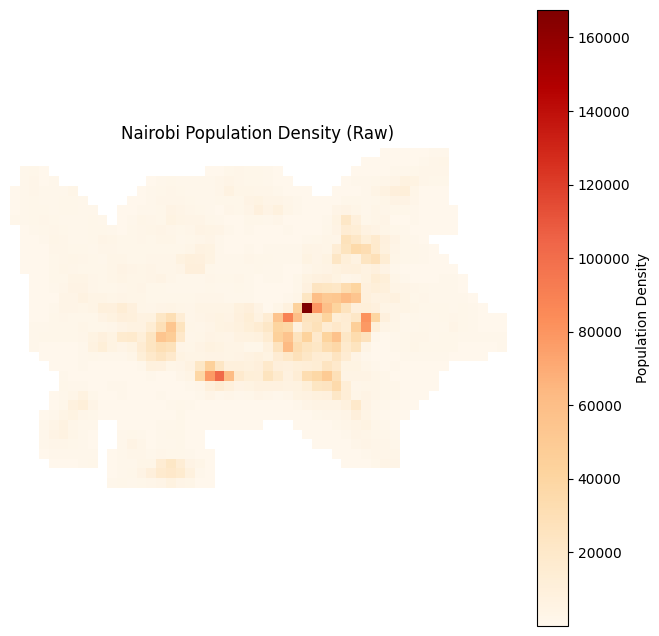

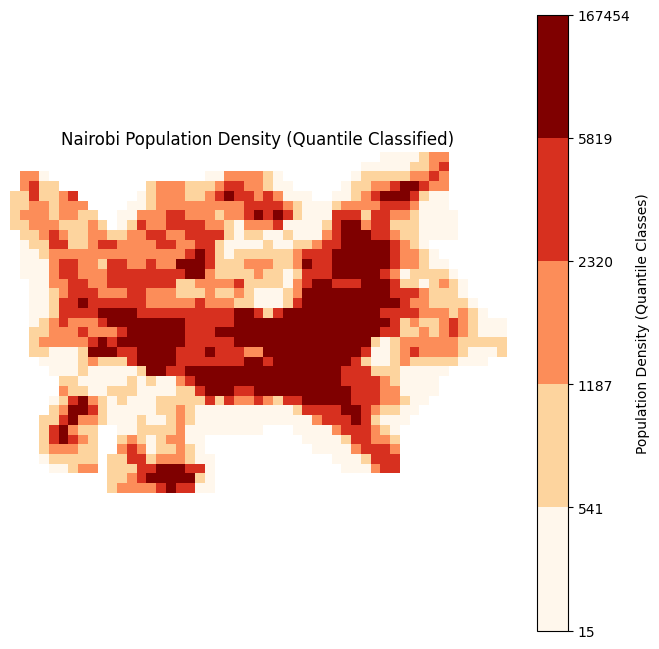




-------------- SUMMARY STATISTICS --------------
Mean: 5469.975434449247
Median: 1634.078125
Std Dev: 11649.471282095566
Min: 15.168525695800781
Max: 167454.390625
Skewness: 5.330478551471498
Coefficient of Variation: 2.129711809806055





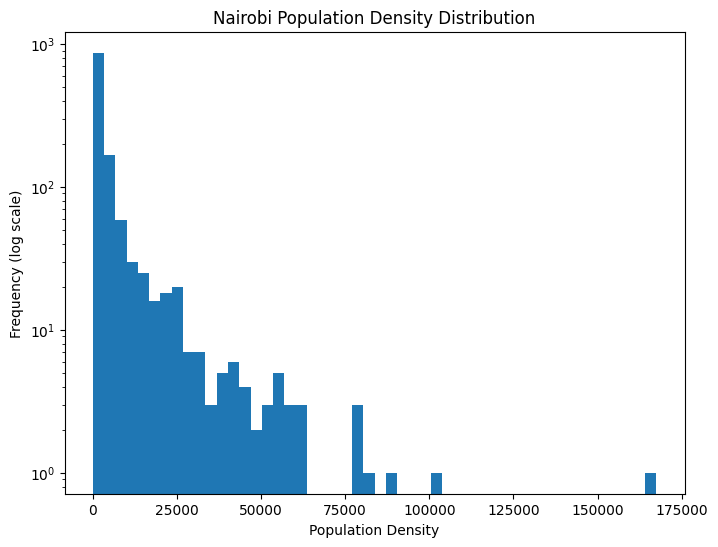

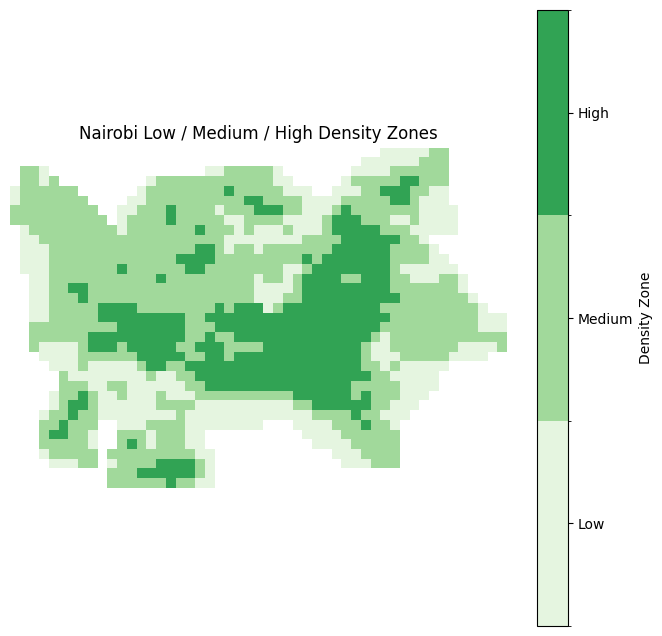




Q1 threshold: 656.8076171875
Q3 threshold: 4404.0625

================================== Mumbai ======================================


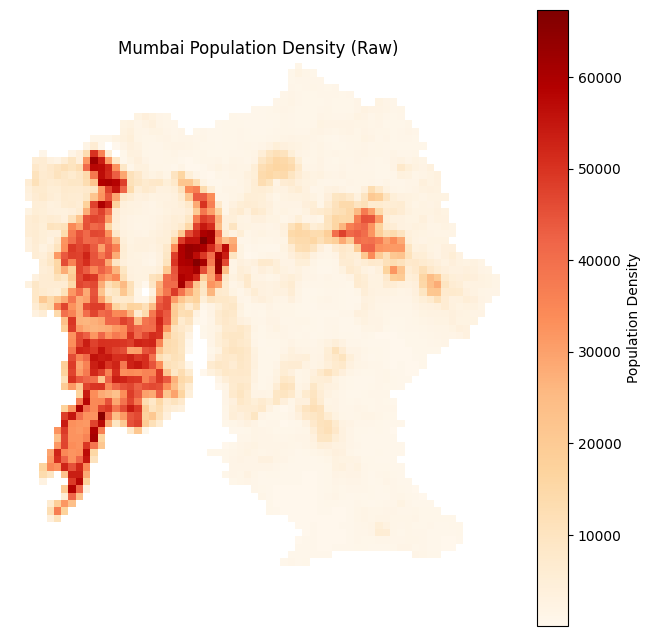

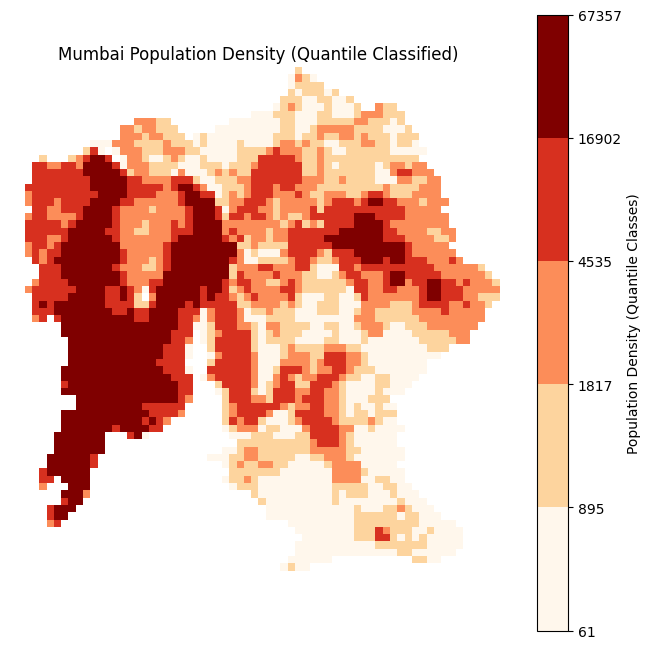




-------------- SUMMARY STATISTICS --------------
Mean: 10455.019448747767
Median: 2643.94580078125
Std Dev: 15590.071562466172
Min: 60.80990219116211
Max: 67357.109375
Skewness: 1.7531406383749852
Coefficient of Variation: 1.4911566294918224





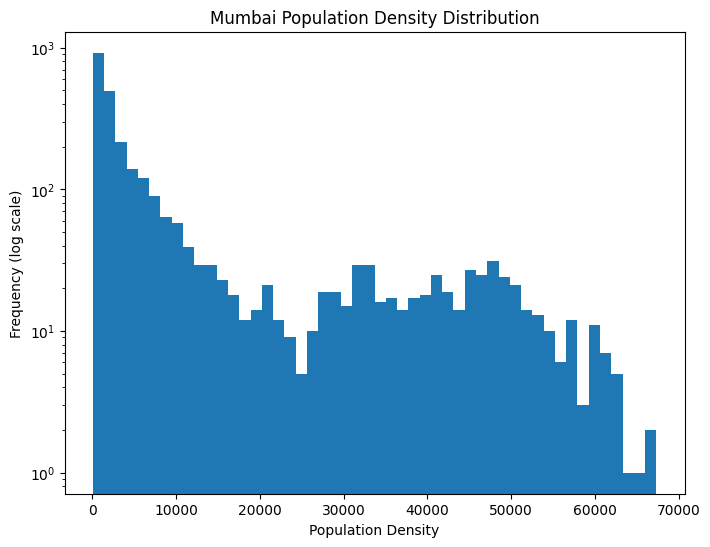

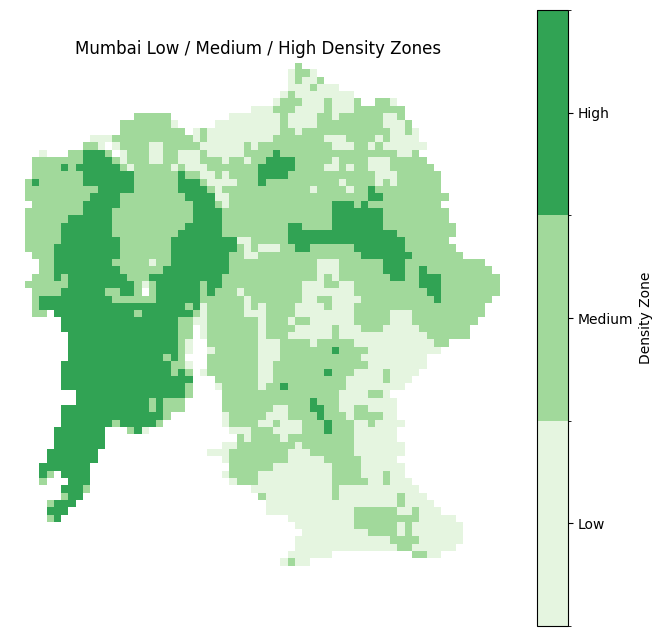




Q1 threshold: 1053.317626953125
Q3 threshold: 10475.267578125

================================== Lagos ======================================


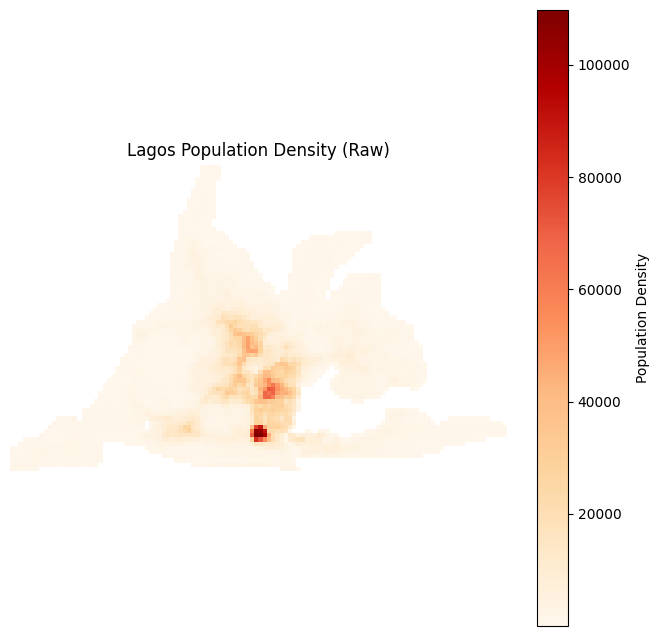

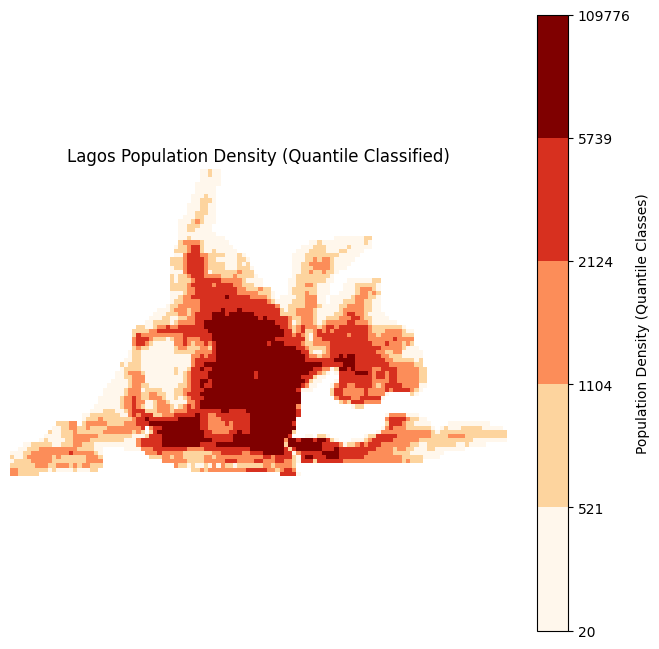




-------------- SUMMARY STATISTICS --------------
Mean: 5074.3305610132065
Median: 1514.8111572265625
Std Dev: 9888.26290437459
Min: 20.230180740356445
Max: 109776.0390625
Skewness: 4.394531585503703
Coefficient of Variation: 1.948683237222955





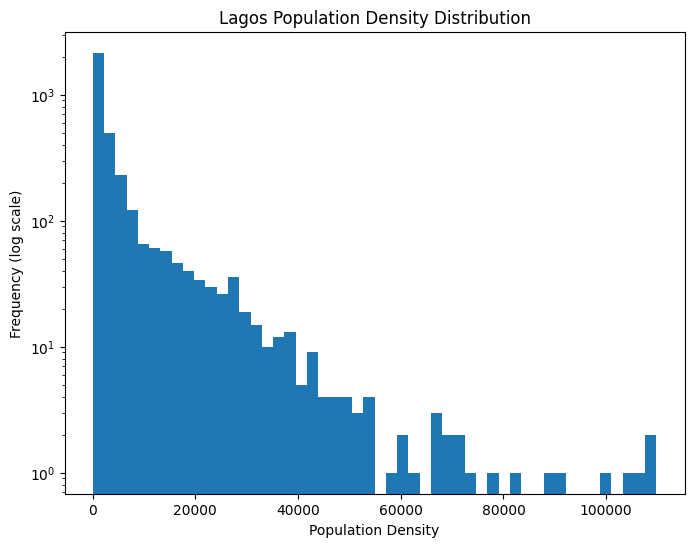

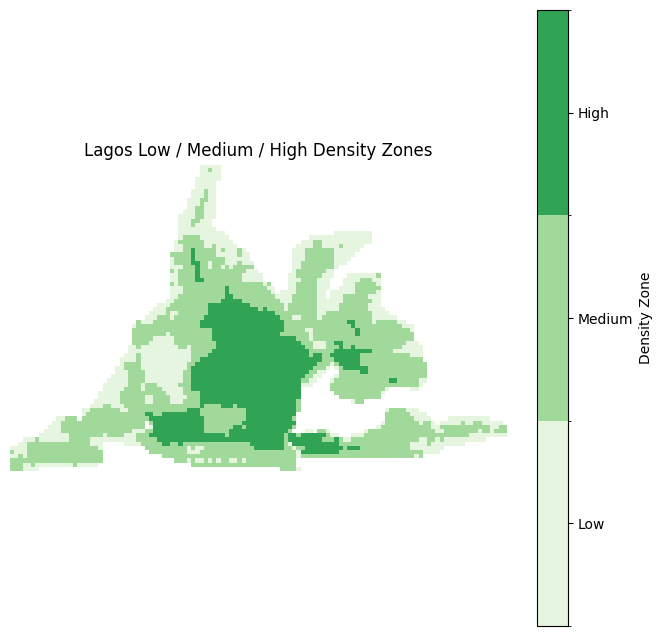




Q1 threshold: 638.137939453125
Q3 threshold: 4339.713623046875

================================== Mexico City ======================================


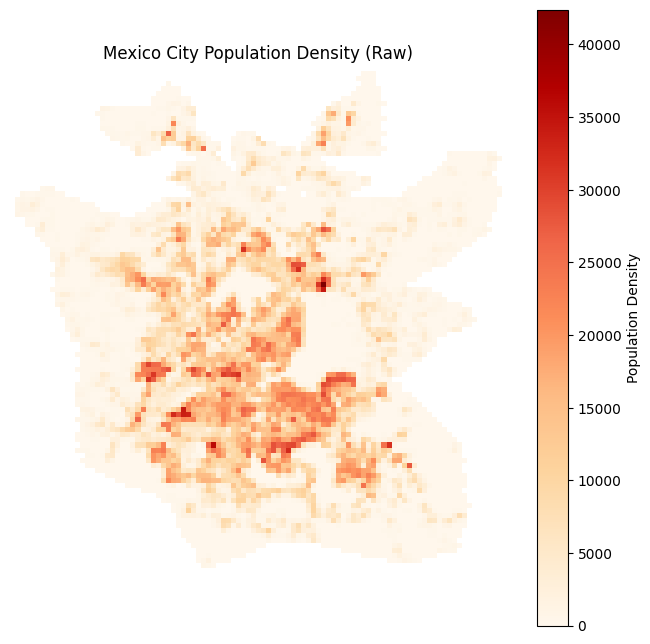

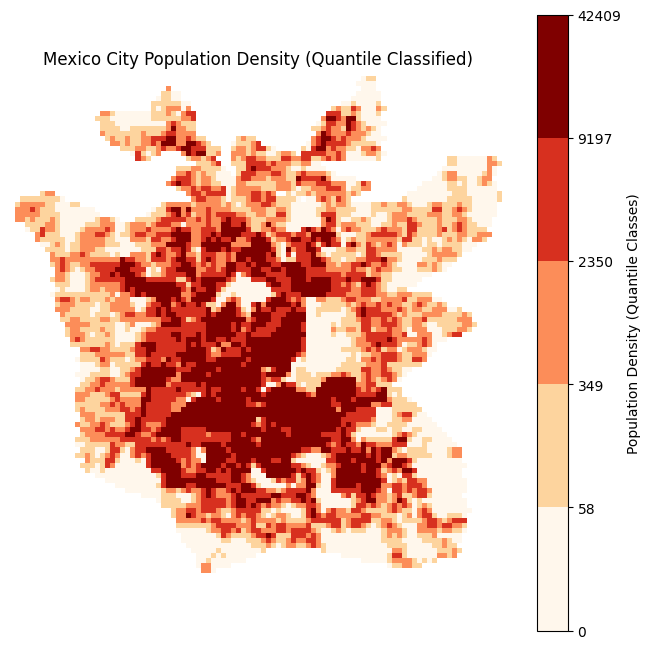




-------------- SUMMARY STATISTICS --------------
Mean: 4585.488814281625
Median: 924.3386535644531
Std Dev: 6681.24277292478
Min: 0.0
Max: 42408.80859375
Skewness: 1.6735773570967591
Coefficient of Variation: 1.457040469080608





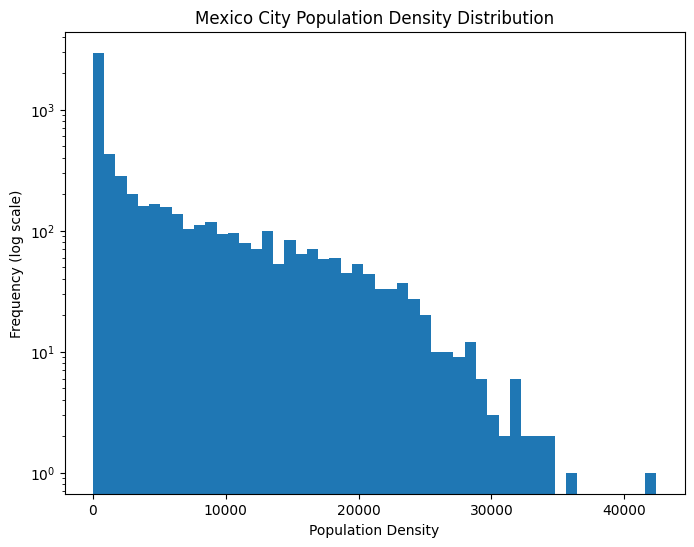

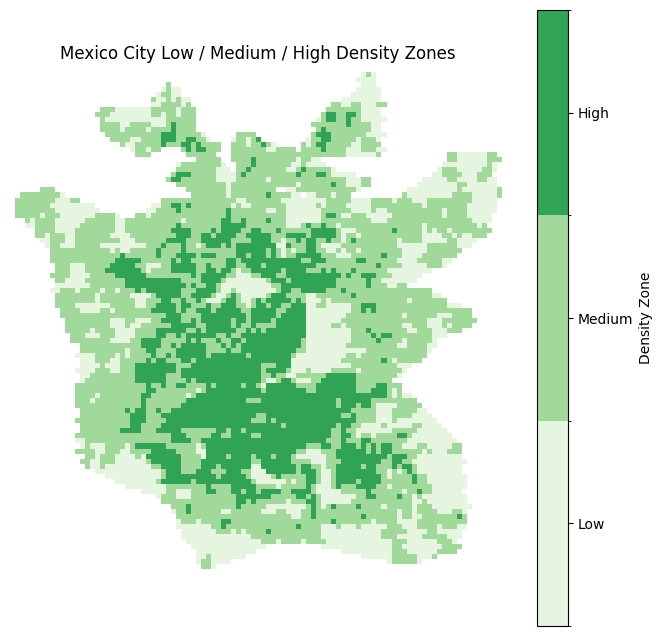




Q1 threshold: 94.74433708190918
Q3 threshold: 6900.4559326171875

================================== Salvador ======================================


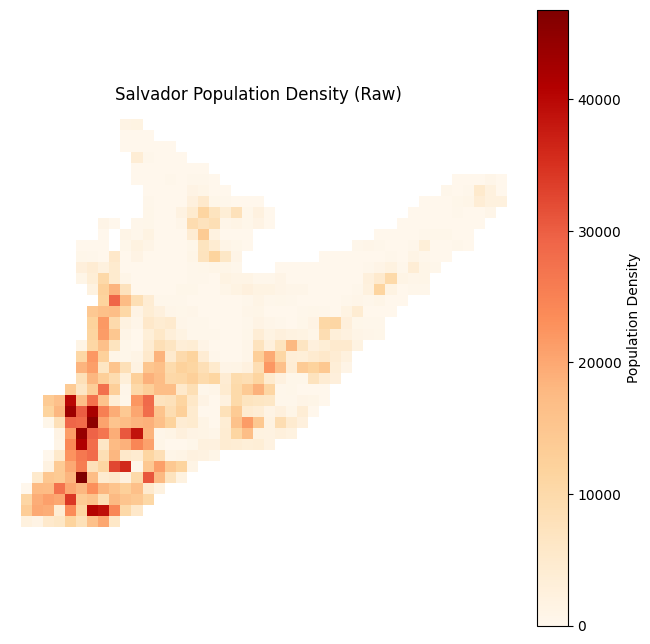

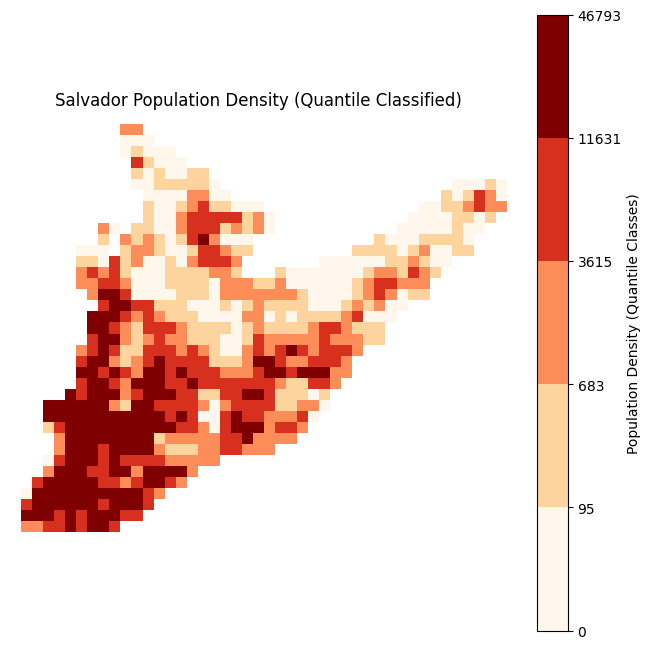




-------------- SUMMARY STATISTICS --------------
Mean: 5892.051486817122
Median: 1464.7059326171875
Std Dev: 8549.774927452017
Min: 0.0
Max: 46793.43359375
Skewness: 1.9496572047904925
Coefficient of Variation: 1.4510692831828247





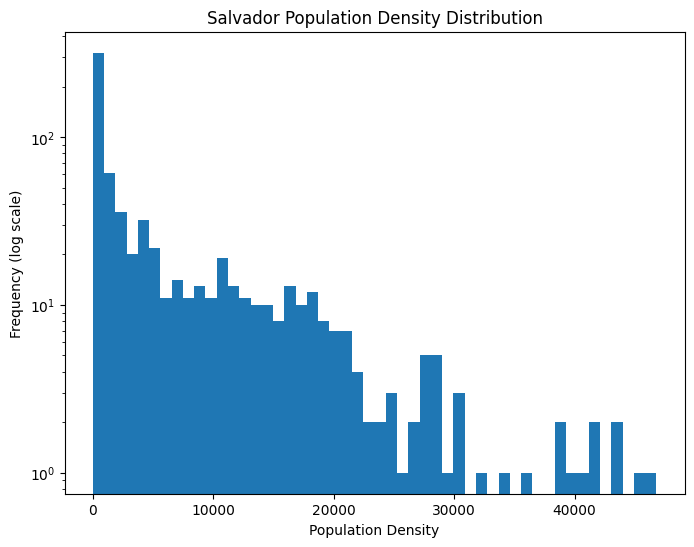

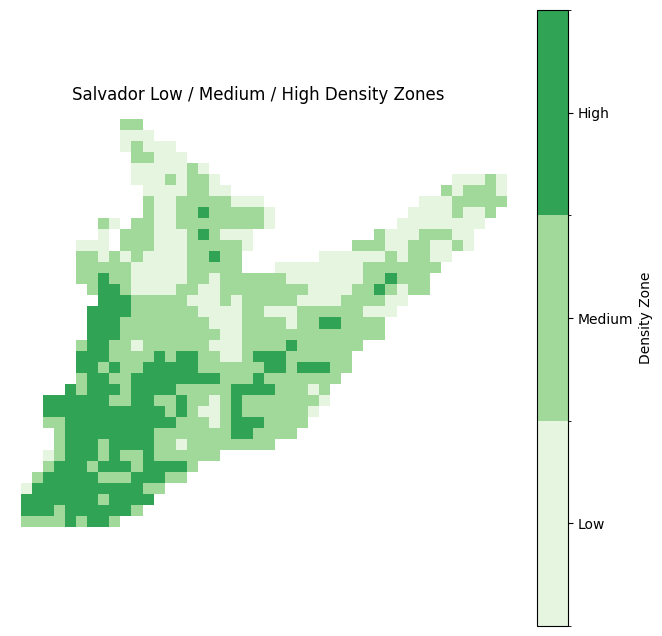




Q1 threshold: 160.96359252929688
Q3 threshold: 9476.380859375

================================== Jakarta ======================================


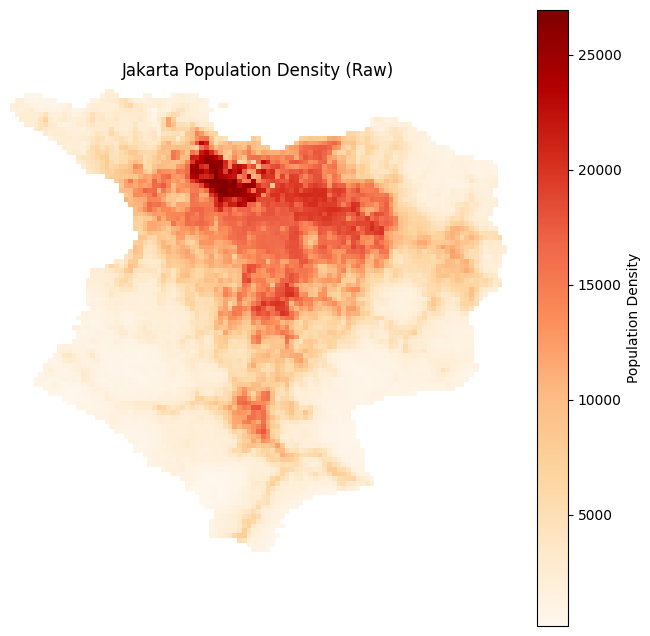

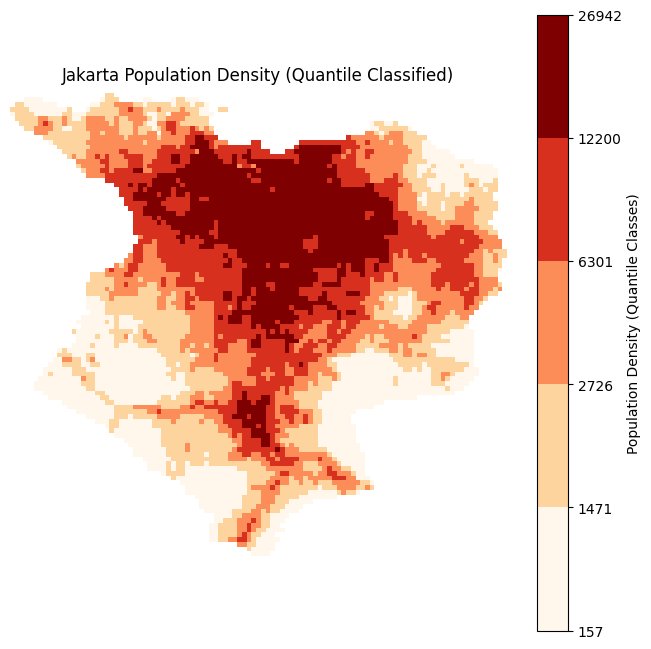




-------------- SUMMARY STATISTICS --------------
Mean: 6583.175393470155
Median: 4404.896240234375
Std Dev: 5969.071472194454
Min: 157.07093811035156
Max: 26942.158203125
Skewness: 1.006640535290093
Coefficient of Variation: 0.9067161537447673





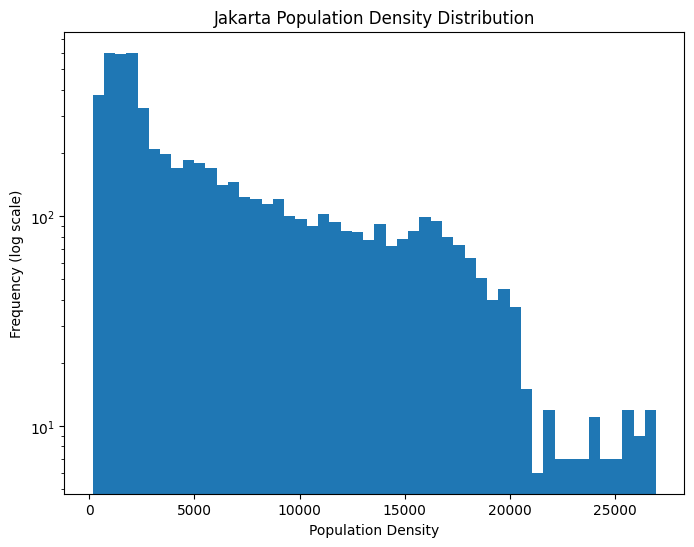

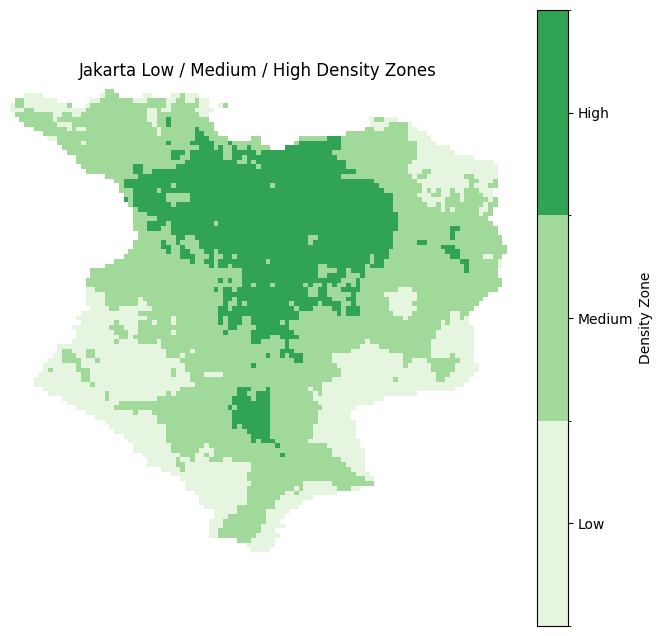




Q1 threshold: 1726.3962097167969
Q3 threshold: 10463.69482421875

================================== Buenos Aires ======================================


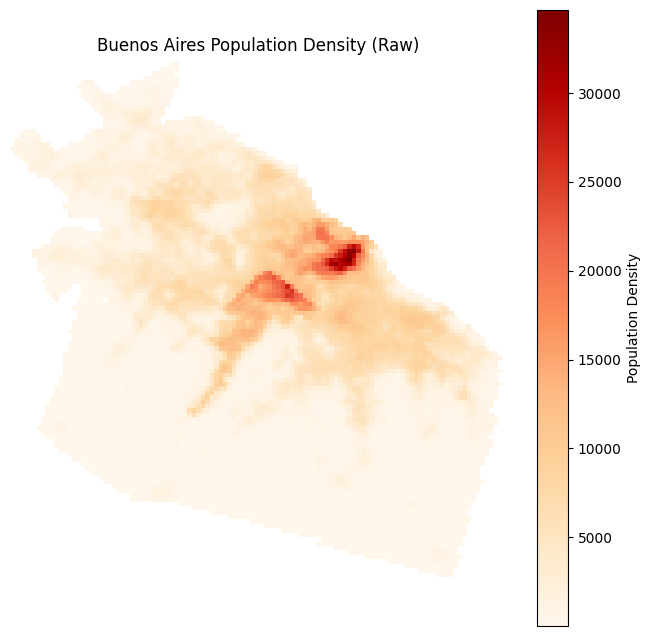

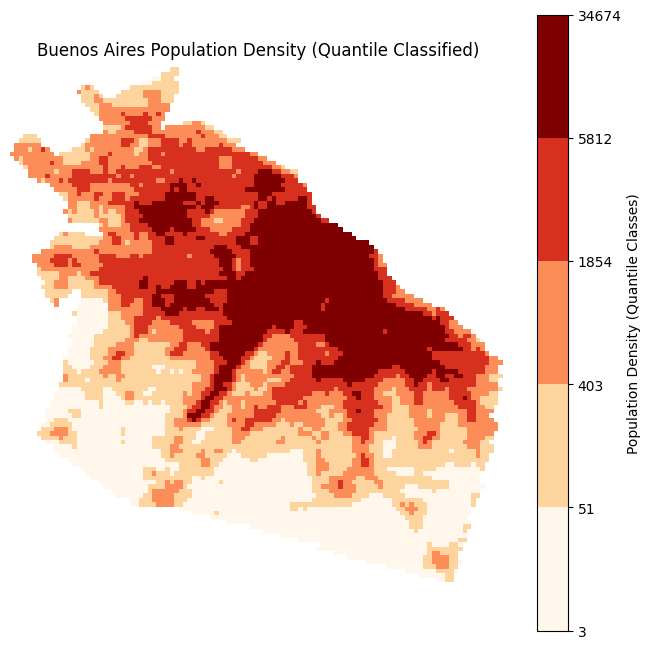




-------------- SUMMARY STATISTICS --------------
Mean: 2970.843984915954
Median: 892.8717651367188
Std Dev: 4312.187632532335
Min: 3.000096082687378
Max: 34673.84375
Skewness: 2.377668544122829
Coefficient of Variation: 1.4515025543000124





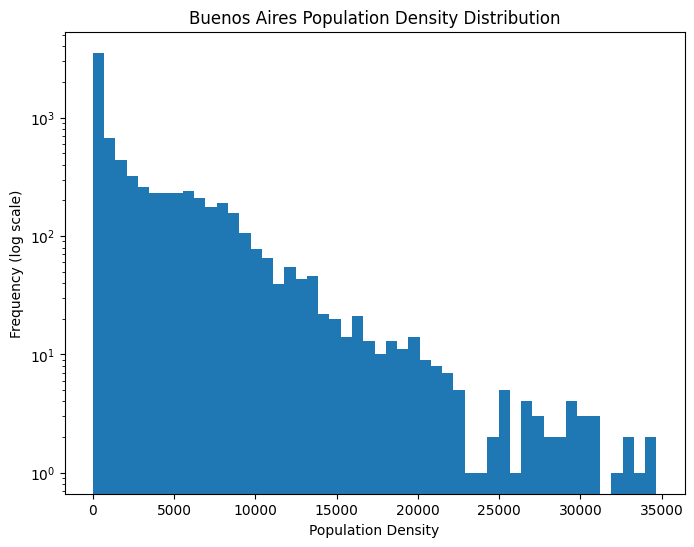

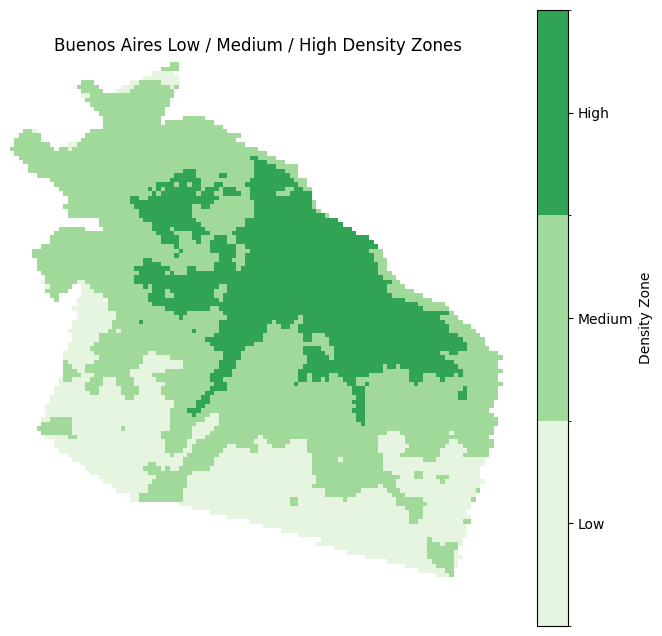




Q1 threshold: 85.02718162536621
Q3 threshold: 4719.701416015625

================================== Medellin ======================================


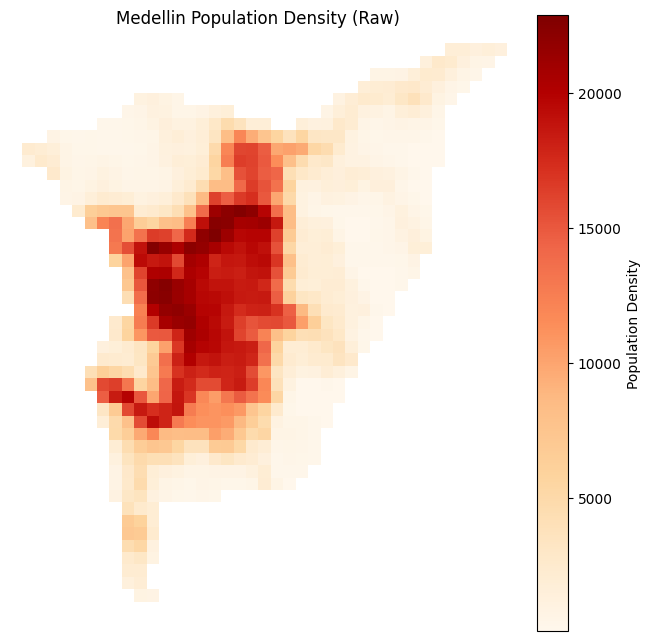

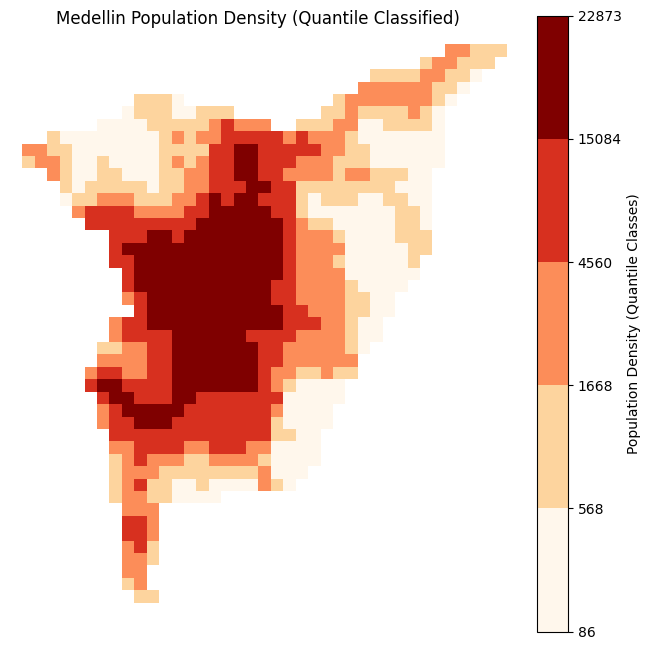




-------------- SUMMARY STATISTICS --------------
Mean: 6419.250826264378
Median: 2359.3837890625
Std Dev: 7160.905836118751
Min: 86.11030578613281
Max: 22873.0625
Skewness: 0.9245974225567444
Coefficient of Variation: 1.1155360695394376





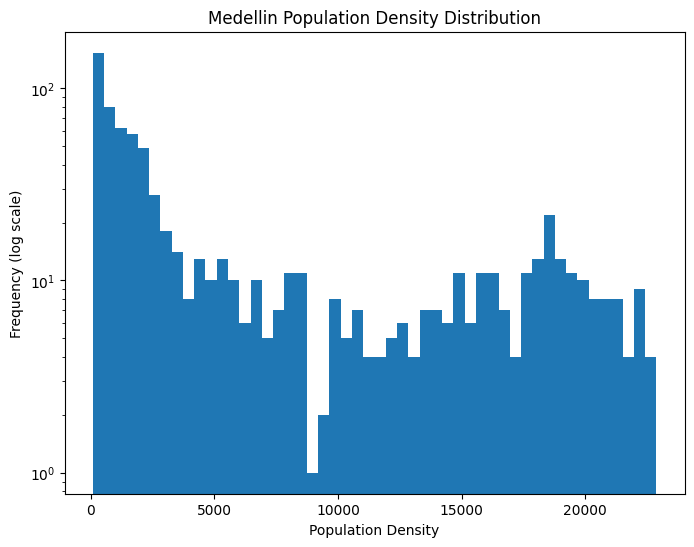

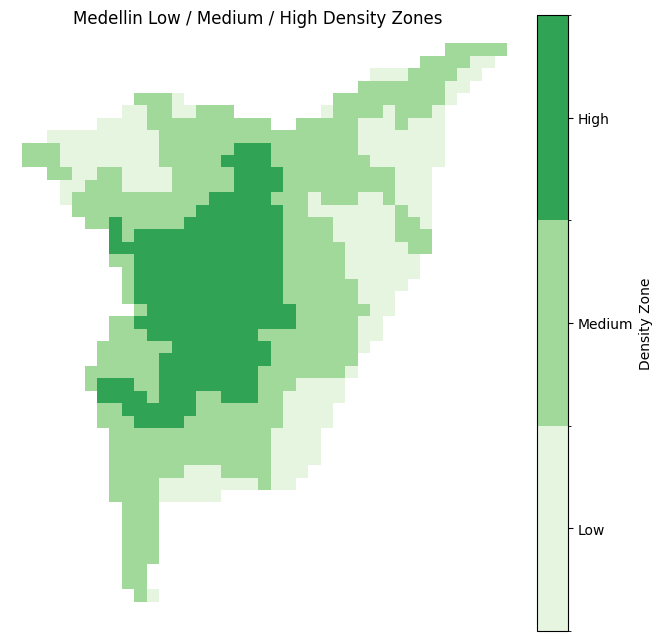




Q1 threshold: 755.8572387695312
Q3 threshold: 12357.26318359375

================================== Accra ======================================


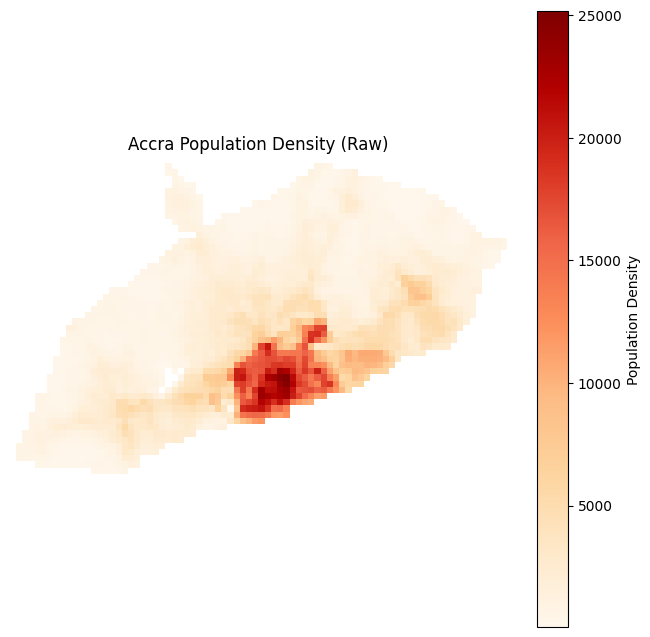

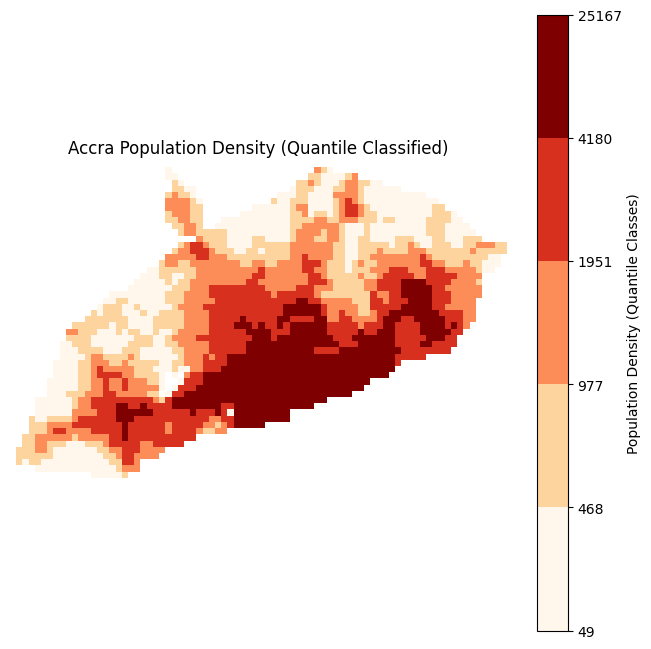




-------------- SUMMARY STATISTICS --------------
Mean: 3124.0204008674623
Median: 1433.1986694335938
Std Dev: 4530.3093477763205
Min: 48.54033279418945
Max: 25166.802734375
Skewness: 2.5468800465002794
Coefficient of Variation: 1.4501535734268467





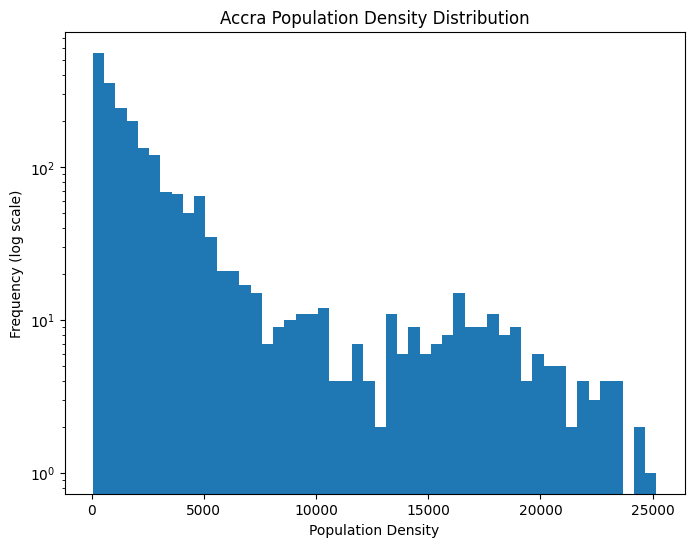

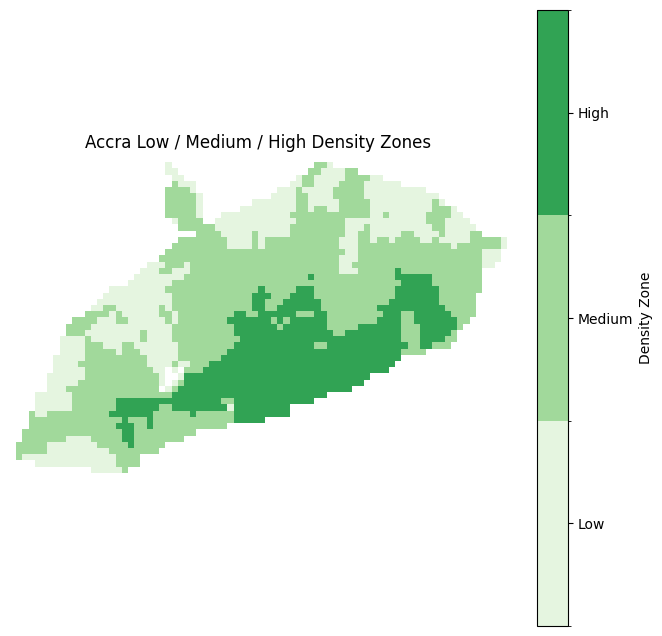




Q1 threshold: 543.3240814208984
Q3 threshold: 3354.4625244140625


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew
from matplotlib.colors import BoundaryNorm, ListedColormap

from google.colab import drive
drive.mount('/content/drive')

# Base path
base_path = "/content/drive/MyDrive/IDEABENCH_PD/"

# Cities dictionary
cities = {
    "Nairobi": "Nairobi_Clipped.tif",
    "Mumbai": "Mumbai_Clipped.tif",
    "Lagos": "Lagos_Clipped.tif",
    "Mexico City": "Mexico_City_Clipped.tif",
    "Salvador": "Salvador_Clipped.tif",
    "Jakarta": "Jakarta_Clipped.tif",
    "Buenos Aires": "BuenosAires_Clipped.tif",
    "Medellin": "Medellin_Clipped.tif",
    "Accra": "Accra_Clipped.tif"
}

# Loop through all cities
for city in cities:

    print(f"\n================================== {city} ======================================")

    path = base_path + cities[city]

    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan

    valid = data[np.isfinite(data)]

    # -------------------------
    # 1. RAW POPULATION MAP
    # -------------------------
    # Raw map shows absolute population density

    plt.figure(figsize=(8,8))
    plt.imshow(data, cmap='OrRd')
    plt.colorbar(label='Population Density')
    plt.title(f"{city} Population Density (Raw)")
    plt.axis('off')
    plt.show()

    print("\n\n")

    # -------------------------
    # 2. QUANTILE CLASSIFIED MAP
    # -------------------------
    # Quantile classification highlights relative spatial distribution

    # Remove NaNs
    valid = data[np.isfinite(data)]

    # Quantile mode with 5 classes
    breaks = np.nanpercentile(valid, [0, 20, 40, 60, 80, 100])

    # Colormap and normalization
    cmap = plt.get_cmap("OrRd", 5)
    norm = BoundaryNorm(breaks, cmap.N)

    # Plot
    plt.figure(figsize=(8,8))
    img = plt.imshow(
        data,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label("Population Density (Quantile Classes)")
    cbar.set_ticks(breaks)  # optional but good

    # Title and formatting
    plt.title(f"{city} Population Density (Quantile Classified)")
    plt.axis("off")

    plt.show()

    print("\n\n")

    # -------------------------
    # 3. SUMMARY STATISTICS
    # -------------------------
    print("-------------- SUMMARY STATISTICS --------------")
    print("Mean:", np.nanmean(valid))
    print("Median:", np.nanmedian(valid))
    print("Std Dev:", np.nanstd(valid))
    print("Min:", np.nanmin(valid))
    print("Max:", np.nanmax(valid))
    print("Skewness:", skew(valid))
    print("Coefficient of Variation:", np.nanstd(valid) / np.nanmean(valid))
    print("\n\n")

    # -------------------------
    # 4. HISTOGRAM
    # -------------------------
    plt.figure(figsize=(8,6))
    plt.hist(valid, bins=50)
    plt.yscale('log')
    plt.title(f"{city} Population Density Distribution")
    plt.xlabel("Population Density")
    plt.ylabel("Frequency (log scale)")
    plt.show()
    print("\n\n")

    # ----------------------------------
    # 5. QUARTILE-BASED CLASSIFICATION
    # ----------------------------------
    # Low / Medium / High Density Zones



    q1 = np.nanpercentile(valid, 25)
    q3 = np.nanpercentile(valid, 75)

    density_class = np.full(data.shape, np.nan)

    density_class[data <= q1] = 1
    density_class[(data > q1) & (data <= q3)] = 2
    density_class[data > q3] = 3

    cmap = ListedColormap([
    "#e5f5e0",  # light (Low)
    "#a1d99b",  # medium
    "#31a354"   # dark (High)
])

    bounds = [1, 2, 3, 4]
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(8,8))
    img = plt.imshow(
        density_class,
        cmap=cmap,
        norm=norm,
        interpolation="nearest"
    )
    #img.set_alpha(~np.isnan(density_class))

    cbar = plt.colorbar(img, ticks=[1.5, 2.5, 3.5])
    cbar.ax.set_yticklabels(["Low", "Medium", "High"])
    cbar.set_label("Density Zone")

    plt.title(f"{city} Low / Medium / High Density Zones")
    plt.axis("off")
    plt.show()
    print("\n\n")

    print("Q1 threshold:", q1)
    print("Q3 threshold:", q3)